In [1]:
datasets = [
    #"mnist_red30_incremental",
    #"mnist_red30_sml",
    #"fashion_mnist_red50_incremental",
    #"fashion_mnist_red50_sml",
    "fashion_mnist_red50_sml_2",
    "fashion_mnist_red50_sml_3",
    "mnist_red30_sml_2",
    "mnist_red30_sml_3",
]
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"
nconfs = 10
save = True
suffixes = []

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def plot_kappa(perf, dataset):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))
    for m in perf:
        ax.plot(perf[m], label=m, linestyle="-")
        ax.scatter(x=np.arange(0,len(perf[m])), y=perf[m], s=15)
    ax.set_xticks(np.arange(0,len(perf[m])))
    ax.set_xticklabels([f"c_{i}" for i in range(0,len(perf[m]))])
    ax.legend(loc="best")
    ax.set_title(dataset)
    ax.set_xlabel("Concepts", loc="right")
    ax.set_ylabel("Cohen's Kappa", loc="top")
    plt.tight_layout()
    plt.grid()
    display(fig)
    if save:
        plt.savefig(os.path.join(root, "performance", f"{dataset}_kappa_cl.png"), dpi=300)
    plt.close(fig)

fashion_mnist_red50_sml_2


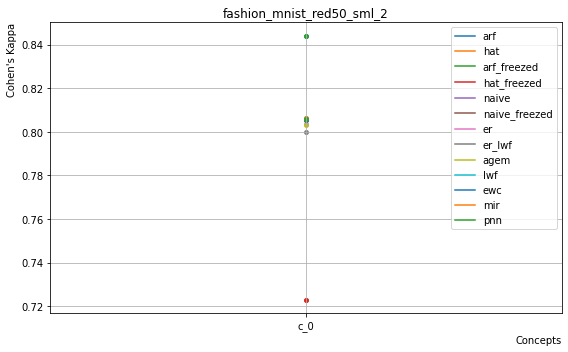

/var/folders/8b/bn5g5hn14bv56xr733msk9tr0000gn/T/ipykernel_81350/3723218332.py:51: RuntimeWarning: invalid value encountered in scalar divide
  "bwt": np.sum(


,model,average,a_metric,bwt
1,arf,0.300045,0.844164,NaN
2,arf_freezed,0.300045,0.844164,NaN
8,lwf,0.283533,0.806271,NaN
9,mir,0.286172,0.806248,NaN
12,pnn,0.285036,0.805866,NaN
5,ewc,0.284347,0.805659,NaN
10,naive,0.286234,0.805348,NaN
11,naive_freezed,0.286234,0.805348,NaN
3,er,0.268876,0.803761,NaN
0,agem,0.267806,0.803202,NaN


fashion_mnist_red50_sml_3


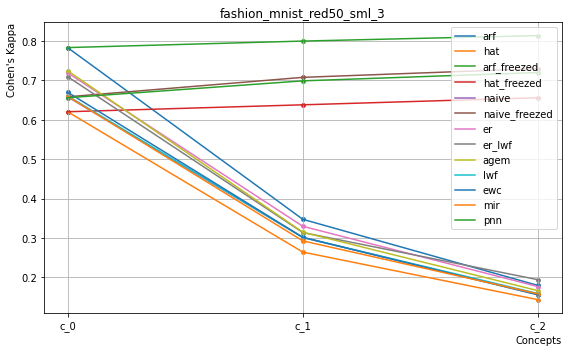

,model,average,a_metric,bwt
2,arf_freezed,0.813394,0.803707,0.000000
11,naive_freezed,0.729626,0.710348,0.000000
12,pnn,0.719783,0.702083,0.000000
7,hat_freezed,0.655835,0.643925,0.000000
1,arf,0.179670,0.336161,-0.935093
4,er_lwf,0.194285,0.320010,-0.800452
3,er,0.176834,0.318173,-0.814040
0,agem,0.166437,0.308864,-0.868385
8,lwf,0.159145,0.290190,-0.843448
5,ewc,0.155810,0.290149,-0.847068


mnist_red30_sml_2


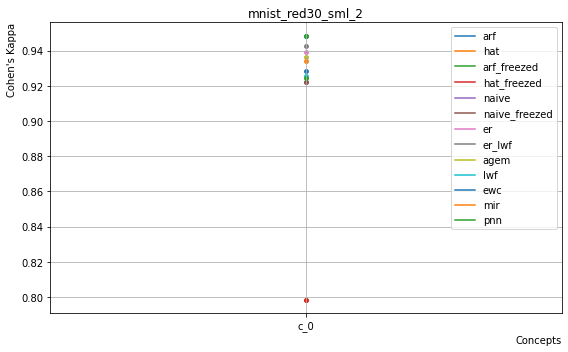

/var/folders/8b/bn5g5hn14bv56xr733msk9tr0000gn/T/ipykernel_81350/3723218332.py:51: RuntimeWarning: invalid value encountered in scalar divide
  "bwt": np.sum(


,model,average,a_metric,bwt
1,arf,0.428710,0.948506,NaN
2,arf_freezed,0.428710,0.948506,NaN
4,er_lwf,0.427767,0.942863,NaN
3,er,0.427987,0.939242,NaN
0,agem,0.430715,0.936625,NaN
9,mir,0.429319,0.934061,NaN
5,ewc,0.428752,0.928355,NaN
8,lwf,0.425988,0.925604,NaN
12,pnn,0.426903,0.924489,NaN
10,naive,0.426200,0.922372,NaN


mnist_red30_sml_3


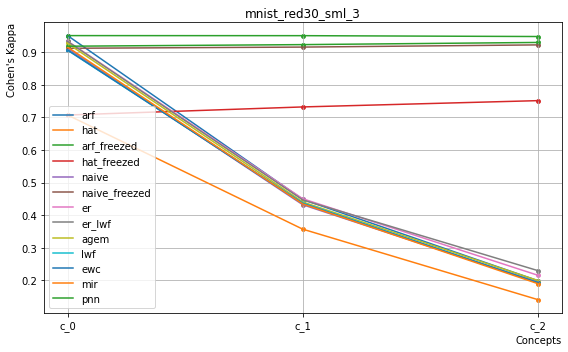

,model,average,a_metric,bwt
2,arf_freezed,0.947767,0.949116,0.000000
12,pnn,0.929637,0.925486,0.000000
11,naive_freezed,0.922123,0.918142,0.000000
7,hat_freezed,0.751184,0.737399,0.000000
4,er_lwf,0.229771,0.419164,-0.951211
3,er,0.215535,0.413421,-0.978646
1,arf,0.198884,0.407269,-1.083695
0,agem,0.199438,0.400890,-1.050437
8,lwf,0.192956,0.393257,-1.048367
10,naive,0.194345,0.393064,-1.050155


In [4]:
if type(nconfs)==int:
    nconfs = [nconfs]*len(datasets)
for dataset, nconf in zip(datasets, nconfs):
    print(dataset)
    cl_tables = []
    for conf in range(1, nconf+1):
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_sml.pkl"), "rb") as f:
            table = pickle.load(f)
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_cl.pkl"), "rb") as f:
            table.update(pickle.load(f))
        for s in suffixes:
            with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"cl_table_cl_{s}.pkl"), "rb") as f:
                table.update(pickle.load(f))
        cl_tables.append(table)
    
    cl_table = {}
    for m in cl_tables[0]:
        cl_table[m] = {}
        for metric in ["accuracy", "kappa"]:
            cl_table[m][metric] = np.mean(np.array([table[m][metric] for table in cl_tables]), axis=0)
    
    cumulative = []
    for conf in range(nconf):
        cumulative.append({})
        for m in cl_tables[conf]:
            cumulative[-1][m] = []
            for i in range(len(cl_tables[conf][m]["kappa"])):
                cumulative[-1][m].append(np.mean(cl_tables[conf][m]["kappa"][i][:i+1]))
                
    cumulative_final = {}
    for m in cumulative[0]:
        cumulative_final[m] = np.mean(np.array([c[m] for c in cumulative]), axis=0)
    
    plot_kappa(cumulative_final, dataset)
    
    cl_metrics = []
    for conf, table in enumerate(cl_tables):
        cl_metrics.append({})
        for m in table:
            n = len(table[m]["kappa"])
            cl_metrics[-1][m] = {
                "average": np.mean(table[m]["kappa"][-1]),
                "a_metric": np.sum(
                    [
                        table[m]["kappa"][i][j]
                        for i in range(n)
                        for j in range(i+1)
                    ]
                )
                / (n * (n + 1) / 2),
                "bwt": np.sum(
                    [
                        (
                            table[m]["kappa"][i][j]
                            - table[m]["kappa"][j][j]
                        )
                        for i in range(1, n)
                        for j in range(i)
                    ]
                ) / (n * (n - 1) / 2),
                "conf": conf+1
            }  
    
    for i in range(len(cl_metrics)):
        cl_metrics[i] = pd.DataFrame(cl_metrics[i]).T.reset_index().rename(columns={'index': 'model'})
        
    cl_metrics = pd.concat(cl_metrics)
    if save:
        cl_metrics.to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics_all.xlsx"), index=False)
    cl_avg = cl_metrics.groupby("model").mean().drop(columns="conf").reset_index().sort_values("a_metric", ascending=False)
    if save:
        cl_avg.to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics.xlsx"), index=False)
    
    display(cl_avg)